In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import platform

In [2]:
if platform.system() == 'Darwin':
    plt.rc('font', family = 'AppleGothic')
else:
    plt.rc('font',family = 'Malgun Gothic')

In [3]:
# apple.csv 파일 로드
df = pd.read_csv('../csv/aapl.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9715 entries, 0 to 9714
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       9715 non-null   object 
 1   Open       9714 non-null   float64
 2   High       9714 non-null   float64
 3   Low        9714 non-null   float64
 4   Close      9714 non-null   float64
 5   Adj Close  9714 non-null   float64
 6   Volume     9713 non-null   float64
dtypes: float64(6), object(1)
memory usage: 531.4+ KB


In [6]:
# read_csv()에서 특정 컬럼의 데이터만 가져온다
# usecols 매개변수를 이용 -> 사용할 컬럼들을 선택( 데이터 파일에 불필요한 컬럼들이 너무 많은 경우 )
df2 = pd.read_csv('../csv/aapl.csv',usecols = ['Date','Adj Close'])

In [8]:
df[['Date','Adj Close']]

,Date,Adj Close
0,1980-12-12,0.410525
1,1980-12-15,0.389106
2,1980-12-16,0.360548
3,1980-12-17,0.369472
4,1980-12-18,0.380182
...,...,...
9710,2019-06-18,198.449997
9711,2019-06-19,197.869995
9712,2019-06-20,199.460007
9713,2019-06-21,198.779999


In [11]:
# 결측치가 포함된 인덱스를 제거 -> 제거,삭제(drop), 결측치(na)
df2.dropna(inplace = True)

In [13]:
df2.head(1)

,Date,Adj Close
0,1980-12-12,0.410525


In [15]:
# 시계열 데이터로 변경
df2['Date'] = pd.to_datetime(df2['Date'])

In [16]:
df2.head(3)

,Date,Adj Close
0,1980-12-12,0.410525
1,1980-12-15,0.389106
2,1980-12-16,0.360548


In [17]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9714 entries, 0 to 9714
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       9714 non-null   datetime64[ns]
 1   Adj Close  9714 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 227.7 KB


<Axes: xlabel='Date'>

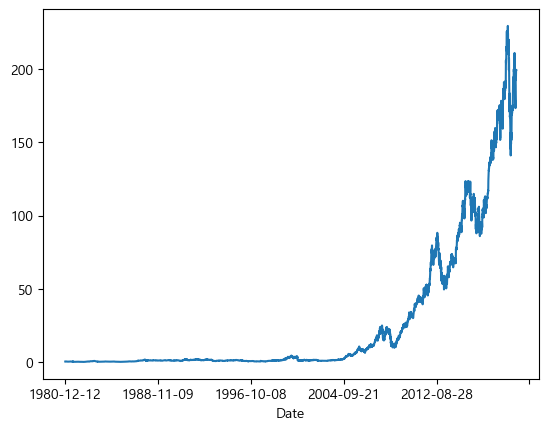

In [20]:
df.set_index('Date')['Adj Close'].plot()

In [22]:
# Date 컬럼을 인덱스로 전환
df2.set_index('Date',inplace = True)

- 이동평균선
    - n(5, 20,60, 120)일 치의 주가의 평균을 구한다

In [27]:
# 인덱스를 n(20)개씩 묶어서 Adj Close의 평균을 구한다
df2.iloc[0:20, 0].mean()
df2.iloc[1:21, 0].mean()

0.4445271

In [28]:
# 이동평균값 컬럼을 먼저 생성 -> 데이터는 0을 대입
df2['이동평균값'] = 0

In [29]:
df2.iloc[19,1] = df2.iloc[0:20,0].mean()

C:\Users\lovek\AppData\Local\Temp\ipykernel_2108\3102367386.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.4432777' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df2.iloc[19,1] = df2.iloc[0:20,0].mean()


In [30]:
df2.head(20)

,Adj Close,이동평균값
Date,,
1980-12-12,0.410525,0.000000
1980-12-15,0.389106,0.000000
1980-12-16,0.360548,0.000000
1980-12-17,0.369472,0.000000
1980-12-18,0.380182,0.000000
1980-12-19,0.403385,0.000000
1980-12-22,0.423019,0.000000
1980-12-23,0.440868,0.000000
1980-12-24,0.464072,0.000000


In [31]:
# 반복 횟수는?
for i in range(len(df2)-19):
    # i가 0부터 시작이면 데이터프레임의 길이에 -20 까지 대입
    df2.iloc[i+19,1] = df2.iloc[i:i+20,0].mean()

In [32]:
df2.tail()

,Adj Close,이동평균값
Date,,
2019-06-18,198.449997,185.4325
2019-06-19,197.869995,185.9960
2019-06-20,199.460007,186.8300
2019-06-21,198.779999,187.7860
2019-06-24,199.169998,188.7960


In [33]:
df2['center'] = 0

i = 0
while True:
    try:
        df2.iloc[i+19,2] = df2.iloc[i:i+20,0].mean()
        i += 1
    except:
        break

C:\Users\lovek\AppData\Local\Temp\ipykernel_2108\791836587.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.4432777' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df2.iloc[i+19,2] = df2.iloc[i:i+20,0].mean()


In [34]:
df2.tail()

,Adj Close,이동평균값,center
Date,,,
2019-06-18,198.449997,185.4325,185.4325
2019-06-19,197.869995,185.9960,185.9960
2019-06-20,199.460007,186.8300,186.8300
2019-06-21,198.779999,187.7860,187.7860
2019-06-24,199.169998,188.7960,188.7960


In [40]:
# 인덱스끼리 묶어서 연산을 해주는 함수가 존재, rolling(n)
df2['center2'] = df2['Adj Close'].rolling(20).mean().fillna(0)

<Axes: xlabel='Date'>

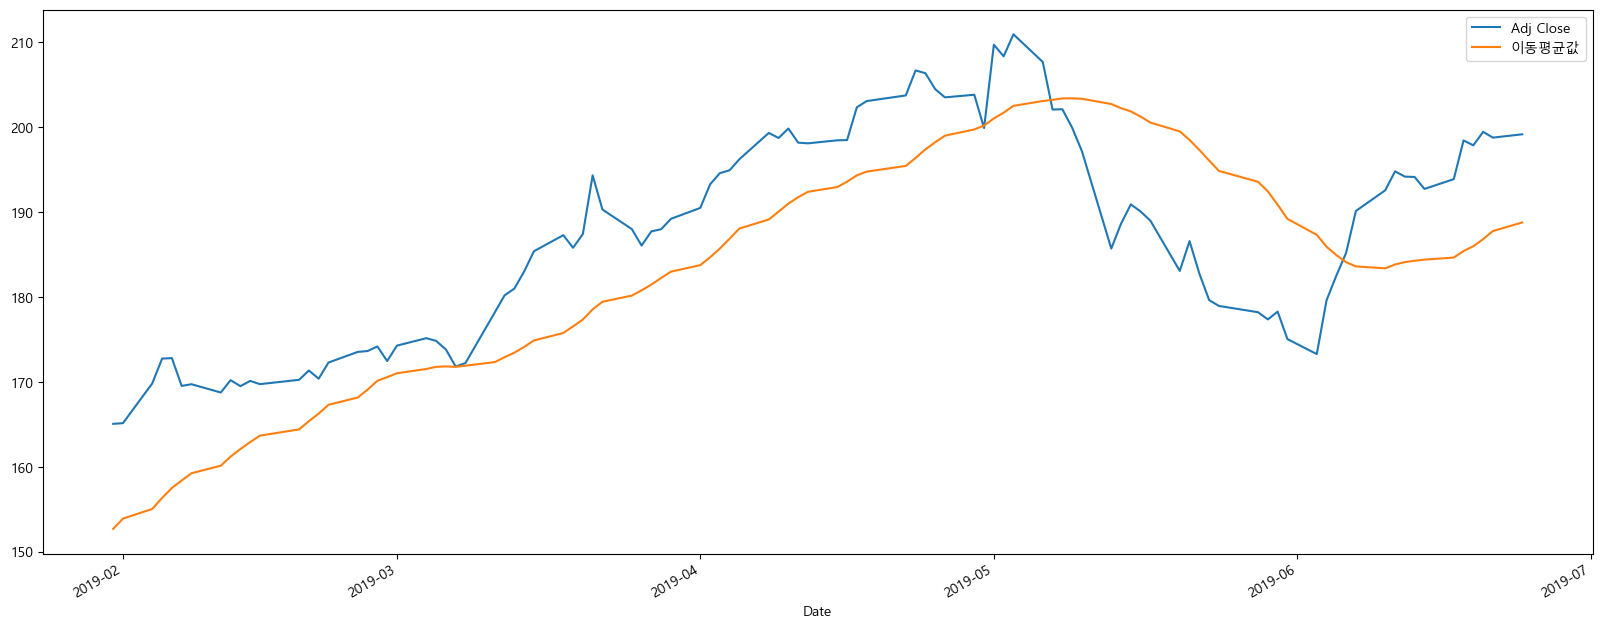

In [45]:
df2[['Adj Close', '이동평균값']].tail(100).plot(figsize = (20,8))

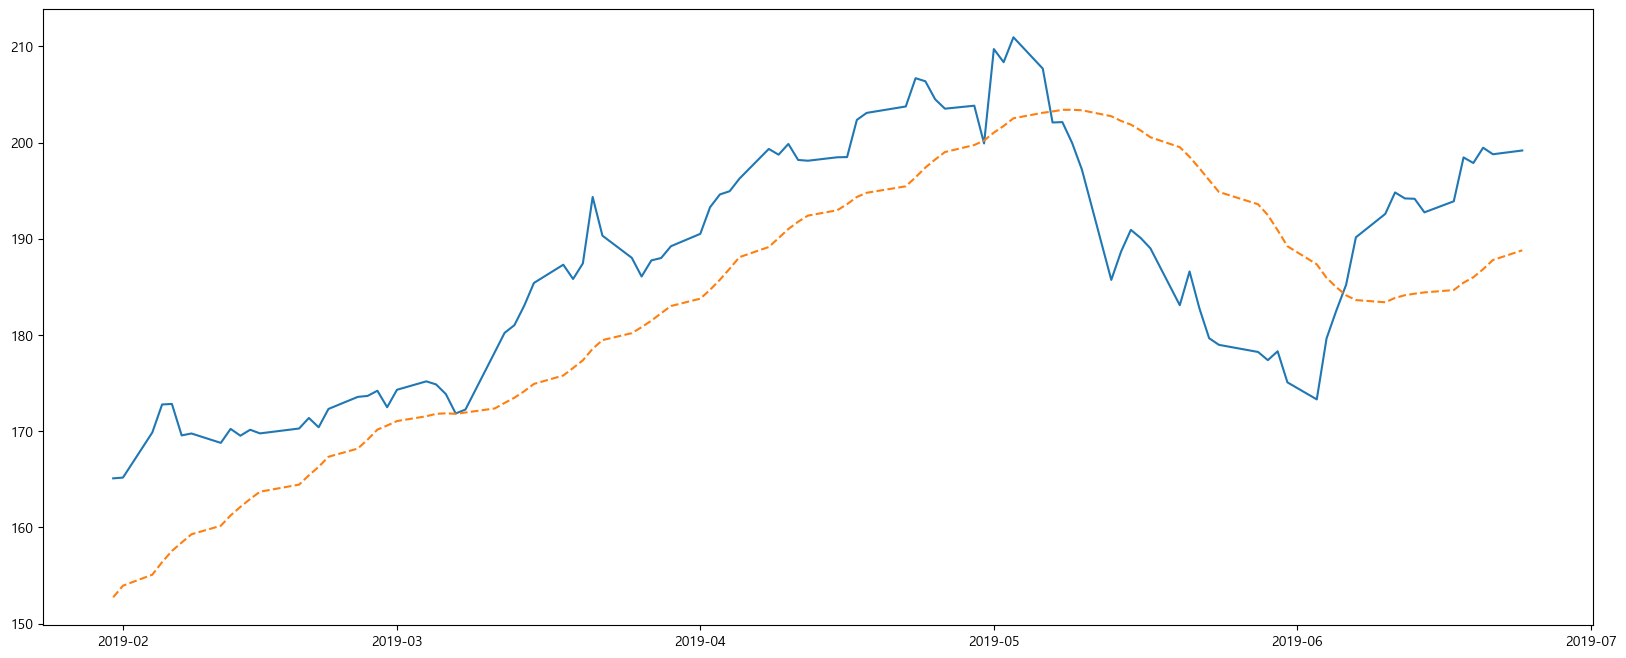

In [ ]:
plt.figure(figsize = (20,8))
plt.plot(df2.tail(100)['Adj Close'])
# 선의 종류를 대쉬 선으로 변경
plt.plot(df2.tail(100)['이동평균값'], '--')

plt.show()

- 상단밴드, 하단밴드
    - 상단밴드 -> 20일 이동평균선 + (2 * 20일 표준편차)
    - 하단밴드 -> 20일 이동평균선 - (2 * 20일 표준편차)

In [49]:
df2['ub'] = df2['center'] + (2*df2['Adj Close'].rolling(20).std())
df2['lb'] = df2['center'] - (2*df2['Adj Close'].rolling(20).std())

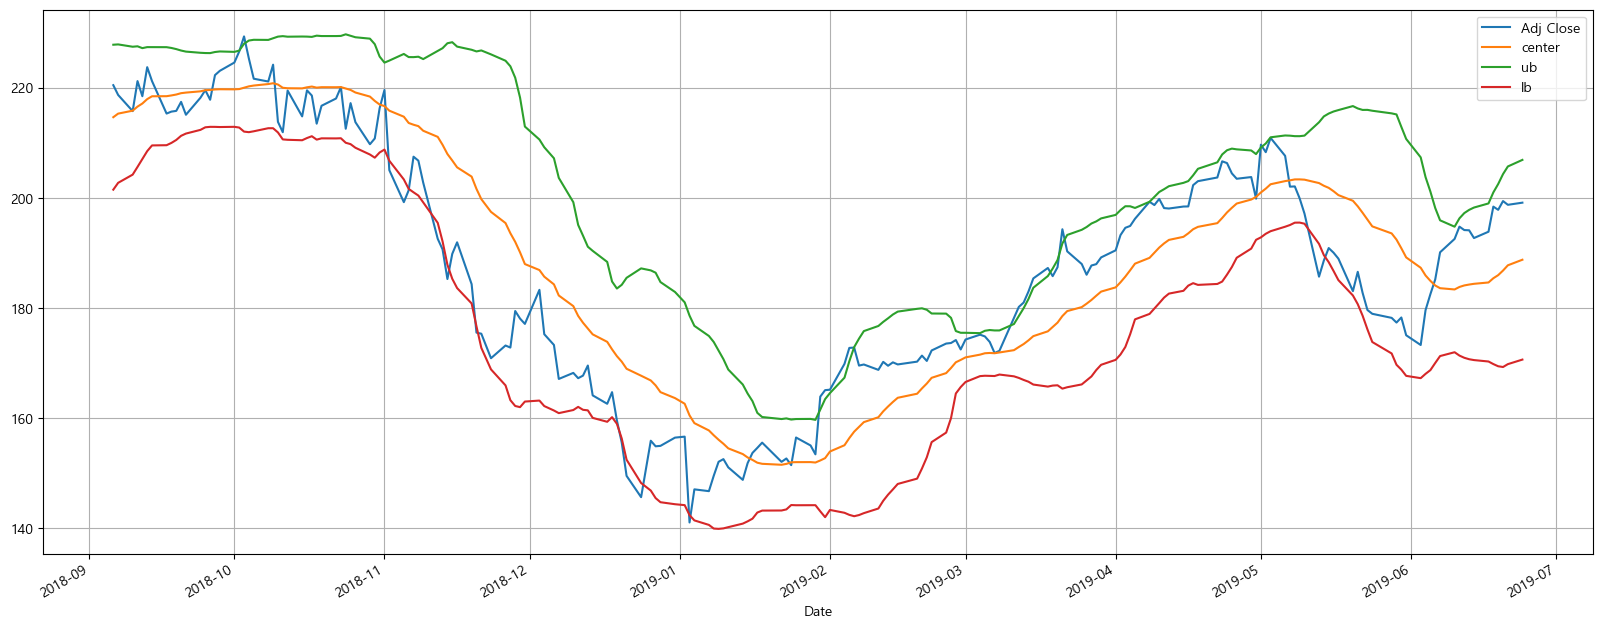

In [57]:
# 최근 100일치 데이터에서 상단 밴드, 하단 밴드, 이동평균선, 종가 그래프에 출력
df2.drop(['이동평균값','Center2','center2'],axis=1).tail(200).plot(figsize=(20,8))
plt.grid(True)